In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Configuración de estilo gráfico
sns.set_theme(style="whitegrid")
np.random.seed(42)

# 1. Generación de un conjunto de datos industrial (Mantenimiento Predictivo)
n_samples = 1000

temperatura = np.random.normal(loc=70, scale=10, size=n_samples) # °C
velocidad_rpm = np.random.normal(loc=1500, scale=200, size=n_samples) # RPM
vibracion = np.random.normal(loc=2.5, scale=0.8, size=n_samples) # mm/s
horas_uso = np.random.uniform(low=100, high=5000, size=n_samples)

# Regla lógica para determinar fallo operativo (1 = Falla, 0 = Normal)
falla = (temperatura > 85) | (vibracion > 4.0) | ((horas_uso > 4000) & (temperatura > 78))
falla = falla.astype(int)

# Crear DataFrame
df = pd.DataFrame({
    'Temperatura_C': temperatura,
    'Velocidad_RPM': velocidad_rpm,
    'Vibracion_mms': vibracion,
    'Horas_Uso': horas_uso,
    'Falla_Operativa': falla
})

print("--- Primeros 5 registros del dataset ---")
print(df.head())

--- Primeros 5 registros del dataset ---
   Temperatura_C  Velocidad_RPM  Vibracion_mms    Horas_Uso  Falla_Operativa
0      74.967142    1779.871087       1.959857  4111.827124                0
1      68.617357    1684.926737       2.384385  4919.479312                0
2      76.476885    1511.926074       1.866064  1372.387111                0
3      85.230299    1370.612644       2.253631  4851.645801                1
4      67.658466    1639.644663       0.985108  2213.045962                0


Configuración de estilo gráfico

/tmp/ipykernel_6199/2672759935.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Falla_Operativa', palette=['#2ecc71', '#e74c3c'])


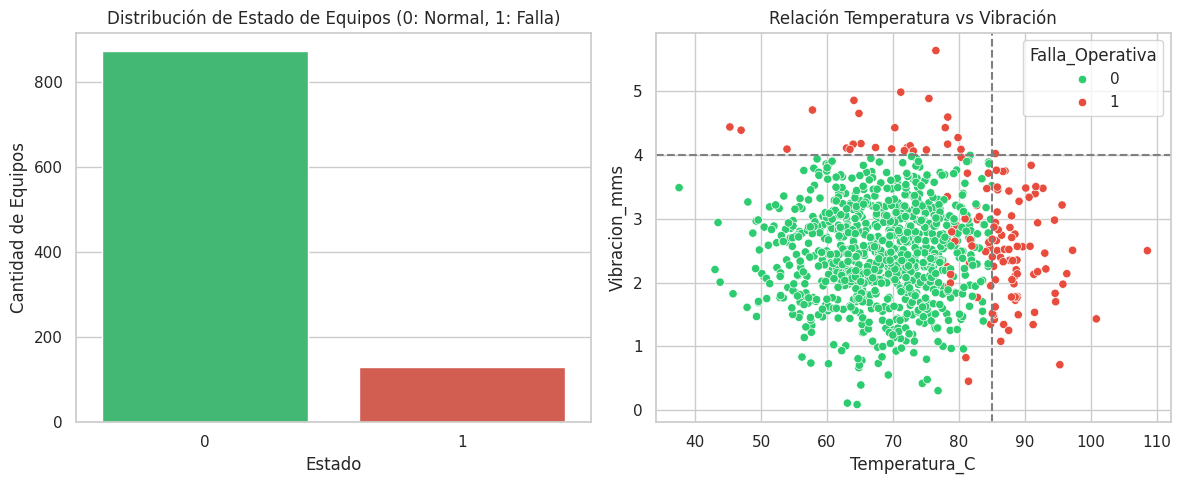

In [4]:
# Visualización de la distribución de fallas
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Falla_Operativa', palette=['#2ecc71', '#e74c3c'])
plt.title('Distribución de Estado de Equipos (0: Normal, 1: Falla)')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Equipos')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Temperatura_C', y='Vibracion_mms', hue='Falla_Operativa', palette=['#2ecc71', '#e74c3c'])
plt.axvline(85, color='gray', linestyle='--')
plt.axhline(4.0, color='gray', linestyle='--')
plt.title('Relación Temperatura vs Vibración')

plt.tight_layout()
plt.show()

In [5]:
# Separación de variables
X = df.drop(columns=['Falla_Operativa'])
y = df['Falla_Operativa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluación
y_pred = model.predict(X_test)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

# Importancia de las variables (Feature Importance)
importancias = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n--- Importancia de las Variables ---")
print(importancias)

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       175
           1       0.96      1.00      0.98        25

    accuracy                           0.99       200
   macro avg       0.98      1.00      0.99       200
weighted avg       1.00      0.99      1.00       200


--- Importancia de las Variables ---
Temperatura_C    0.700563
Vibracion_mms    0.199362
Horas_Uso        0.082053
Velocidad_RPM    0.018022
dtype: float64
